In [2]:
import pandas as pd
df=pd.read_csv("loan_approval_dataset.csv")
print("Loaded")


Loaded


In [3]:
print(df.head(5))

   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  \
0                  1760000

In [4]:
print(df.tail())
print(df.info())
print(df.describe)
print(df.shape)

      loan_id   no_of_dependents      education  self_employed   income_annum  \
4264     4265                  5       Graduate            Yes        1000000   
4265     4266                  0   Not Graduate            Yes        3300000   
4266     4267                  2   Not Graduate             No        6500000   
4267     4268                  1   Not Graduate             No        4100000   
4268     4269                  1       Graduate             No        9200000   

       loan_amount   loan_term   cibil_score   residential_assets_value  \
4264       2300000          12           317                    2800000   
4265      11300000          20           559                    4200000   
4266      23900000          18           457                    1200000   
4267      12800000           8           780                    8200000   
4268      29700000          10           607                   17800000   

       commercial_assets_value   luxury_assets_value   bank_as

In [5]:
print(df.columns)

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')


In [6]:
print(df.isnull().sum())

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64


In [7]:
print(df.duplicated().sum())

0


In [8]:
df.columns=df.columns.str.strip()

In [9]:
print(df.columns)

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')


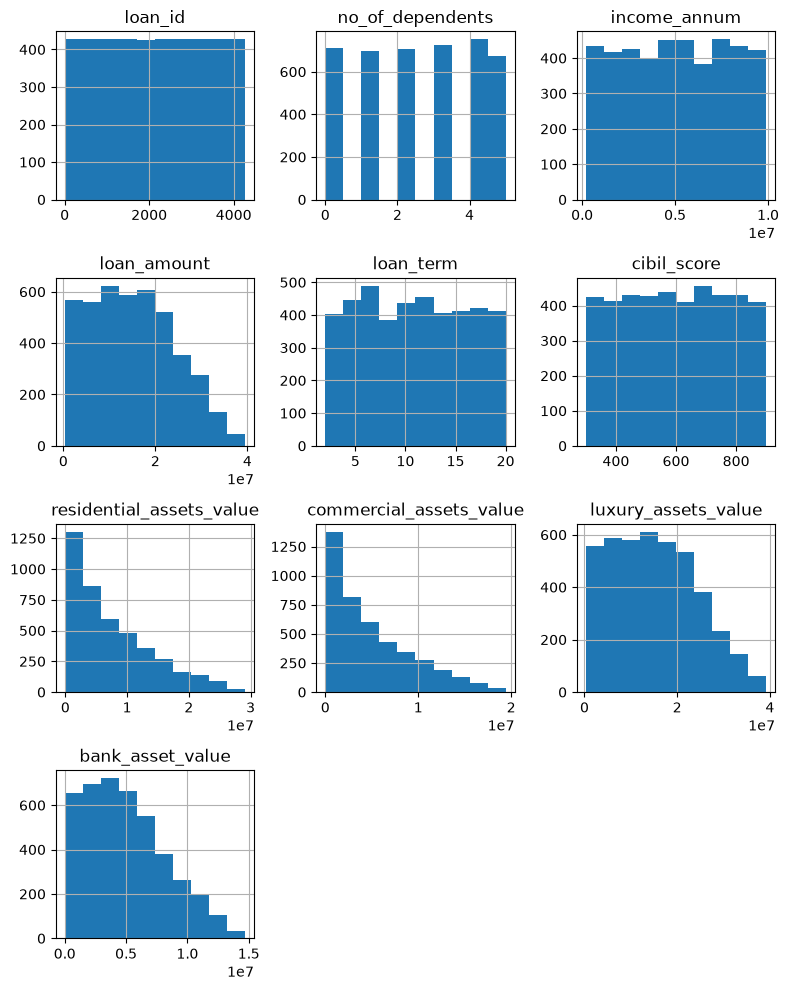

In [18]:
import matplotlib.pyplot as plt


df.hist(figsize=(8,10))
plt.tight_layout()
plt.show()

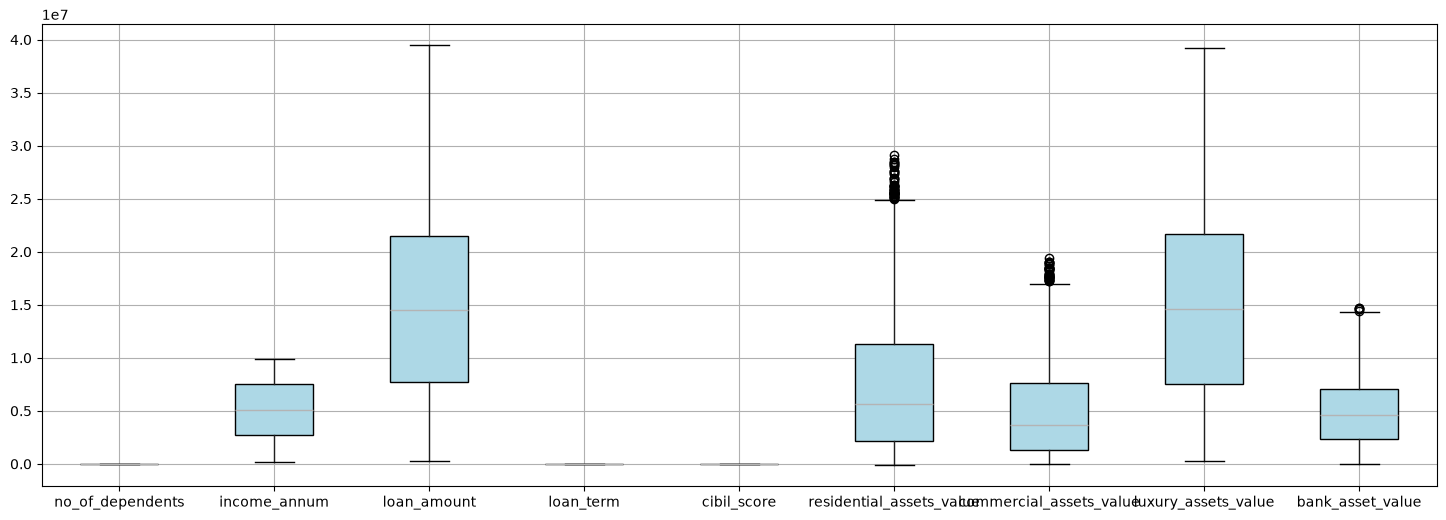

In [24]:
plt.figure(figsize=(18,6))
df.drop("loan_id",axis=1).boxplot(
    patch_artist=True,
    boxprops=dict(facecolor="lightblue")
)
plt.show()

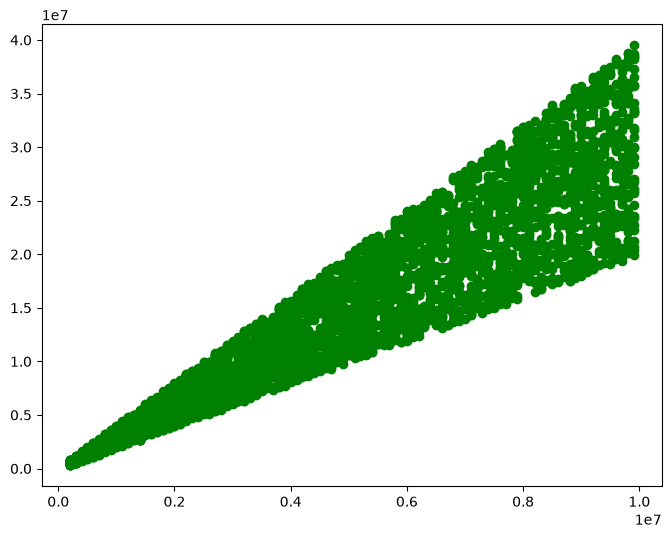

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(df["income_annum"],df["loan_amount"],color="green")
plt.show()

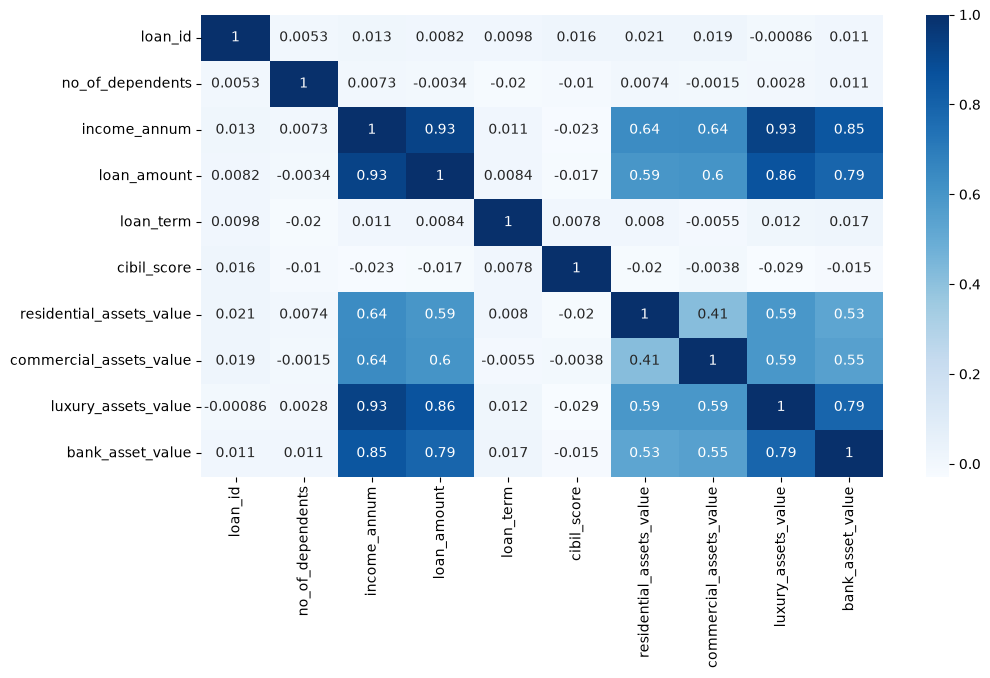

In [31]:
import seaborn as sns

corr=df.select_dtypes(include="number").corr()
plt.figure(figsize=(11,6))
sns.heatmap(corr,annot=True,cmap="Blues")
plt.show()

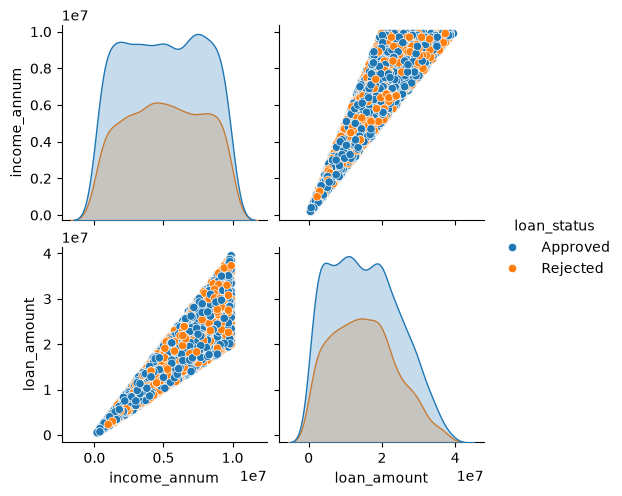

In [32]:
sns.pairplot(df[["income_annum","loan_amount","loan_status"]],hue="loan_status")
plt.show()

In [33]:
print(df.isnull().sum())

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


In [34]:
print(df.duplicated().sum())

0


In [37]:
from sklearn.preprocessing import LabelEncoder

le_edu=LabelEncoder()
le_self=LabelEncoder()
le_status=LabelEncoder()

df["education"]=le_edu.fit_transform(df["education"])
df["self_employed"]=le_self.fit_transform(df["self_employed"])
df["loan_status"]=le_status.fit_transform(df["loan_status"])
print("Encoded")


Encoded


In [48]:
from sklearn.model_selection import train_test_split
x=df.drop("loan_status",axis=1)
y=df["loan_status"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(3415, 12)
(3415,)
(854, 12)
(854,)


In [49]:
print(x_train.head(5))
print(y_train.head(5))
print(x_test.head(5))
print(y_test.head(5))

      loan_id  no_of_dependents  education  self_employed  income_annum  \
1675     1676                 5          1              0       7900000   
1164     1165                 0          1              1       9600000   
192       193                 1          0              0        800000   
910       911                 2          0              1       4900000   
567       568                 5          0              1       3000000   

      loan_amount  loan_term  cibil_score  residential_assets_value  \
1675     29900000          6          568                   5800000   
1164     34000000         12          710                  23800000   
192       2900000          8          682                   2200000   
910      13100000         18          754                   8200000   
567      11100000         12          441                   8500000   

      commercial_assets_value  luxury_assets_value  bank_asset_value  
1675                 13900000             15900000 

In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model=DecisionTreeClassifier()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9742388758782201


In [68]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)
cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 0.8220140515222483
[[492  44]
 [108 210]]


In [70]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred)
print(cm)
print(x_train.min())

[[492  44]
 [108 210]]
loan_id                          1
no_of_dependents                 0
education                        0
self_employed                    0
income_annum                200000
loan_amount                 300000
loan_term                        2
cibil_score                    300
residential_assets_value   -100000
commercial_assets_value          0
luxury_assets_value         300000
bank_asset_value                 0
dtype: int64


In [71]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

select=SelectKBest(score_func=f_classif,k=1)
x=select.fit_transform(x_train,y_train)
print(select.scores_)
print(x_train.columns[select.get_support()])

[2.42640841e+00 1.24312581e+00 7.15642611e-02 2.34177681e-02
 1.64712001e+00 3.00599772e-01 4.61939191e+01 5.01831749e+03
 1.72011306e+00 1.99687712e-01 1.26013875e+00 6.72606504e-01]
Index(['cibil_score'], dtype='str')


In [72]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87       536
           1       0.83      0.66      0.73       318

    accuracy                           0.82       854
   macro avg       0.82      0.79      0.80       854
weighted avg       0.82      0.82      0.82       854

